In [1]:
import fix_import
from database import Deviations
import matplotlib.pyplot as plt
from vars import KMirrorSide, SurfaceType
from scipy.stats import linregress

In [2]:
plot_width = 15
plot_height = 50
plt.rcParams['figure.figsize'] = [plot_width, plot_height]

nrows = 10
ncols = 2

Канал 8


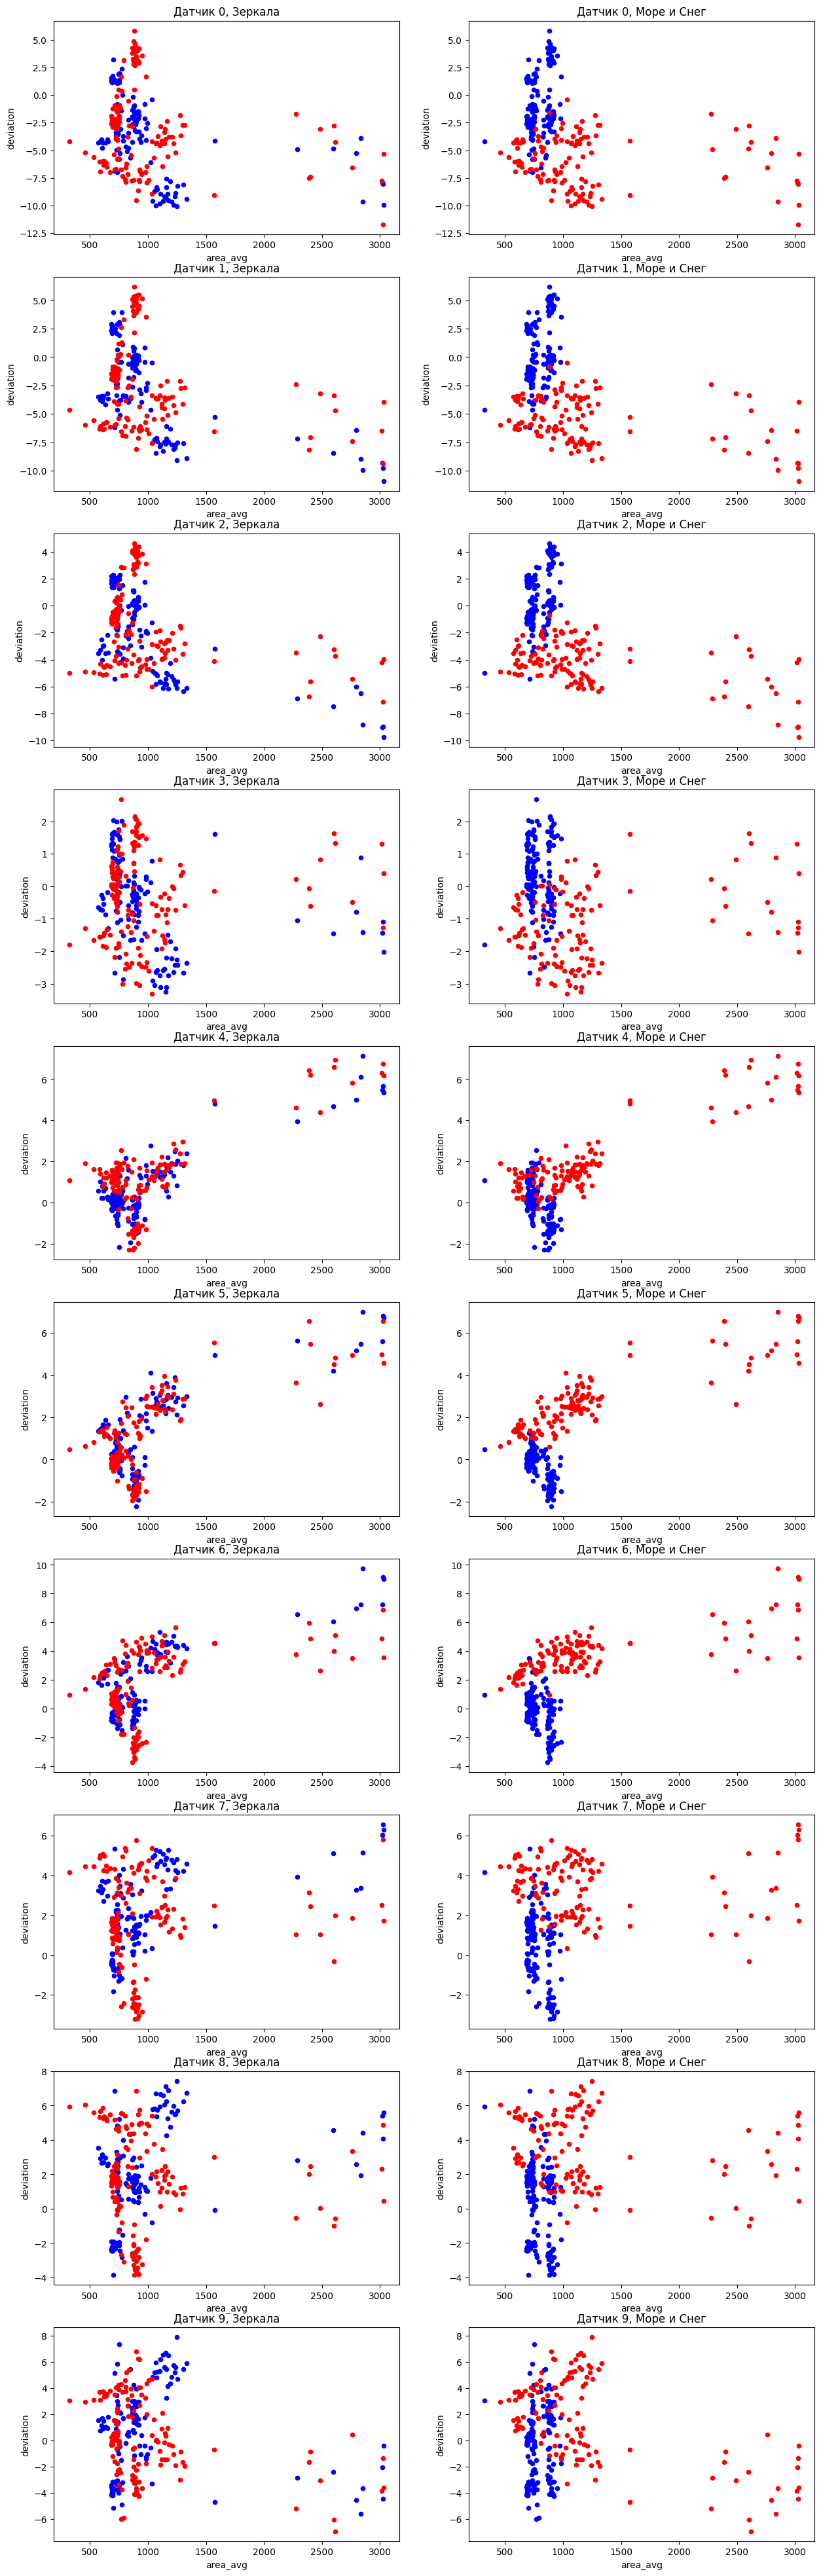

In [4]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols)

year = 2023
channel = 8

for sensor in range(10):
    side1 = Deviations.get_dataframe(year=year, channel=channel, sensor=sensor, k_mirror_side=KMirrorSide.SIDE_1)
    side2 = Deviations.get_dataframe(year=year, channel=channel, sensor=sensor, k_mirror_side=KMirrorSide.SIDE_2)

    sea = Deviations.get_dataframe(year=year, channel=channel, sensor=sensor, surface_type=SurfaceType.SEA)
    snow = Deviations.get_dataframe(year=year, channel=channel, sensor=sensor, surface_type=SurfaceType.SNOW)

    axes[sensor, 0].title.set_text(f"Датчик {sensor}, Зеркала")
    side1.plot(ax=axes[sensor, 0], x="area_avg", y="deviation", kind="scatter", color="b")
    side2.plot(ax=axes[sensor, 0], x="area_avg", y="deviation", kind="scatter", color="r")

    axes[sensor, 1].title.set_text(f"Датчик {sensor}, Море и Снег")
    sea.plot(ax=axes[sensor, 1], x="area_avg", y="deviation", kind="scatter", color="b")
    snow.plot(ax=axes[sensor, 1], x="area_avg", y="deviation", kind="scatter", color="r")

print(f"Канал {channel}")
plt.show()